# Some visualizations for the data we colected on each model

### Implementation
I will start by getting all the metrics for each model in a function and then I will plot them side by side for the user to see

I will use the same features and train test splits so as to get a proper comparsion

### Metrics to be used
- f1 score
- Measn squared error
- Confusion matrix variables. True Positives, True negatives, Fasle Positives, False Negatives
- Features that were relied on the most and the least

### Importing Libraries to be used

In [207]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import os
from sklearn.inspection import permutation_importance
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import f1_score, confusion_matrix, classification_report,mean_absolute_error, r2_score,mean_squared_error

### Importing the different m,odels form files my colleagues and I have worked on

In [208]:
%store -r dt rf gbr gbc knn mlp_balanced mlp 
#dt - Decision Tree
# rf -  Random Forest
# mlp - Multilayer perceptron
# knn - K- Nearest neighbour Classification
# 
modelsToTest = {
    "DT" : dt,
    "RF" :rf,
    "GBR":gbr,
    "GBC":gbc,
    "KNN":knn,
    "MLP":mlp,
    "MLP_B":mlp_balanced,

}

### To make them comparable I will use the same features , and train test splits for every model

In [209]:
# Collecting the data Set 

script_dir = os.getcwd()
rel_path = "intermediate"

dataset = pd.read_csv(os.path.join(script_dir, rel_path, "CLEAN_data_injection_moulding.csv"))

#Stating the features will the cycle time removed 
features = [
    'ZSx [s]',        # injection time
    'ACPx [cm³]',     # cushion volume
    'ZDx [s]',        # dosing time
            # cycle time  'ZUs [s]', 
    'ZEx [s]',        # (keep if it’s meaningful in your process)
    'GEx [kWh]',      # energy consumption

    'H16x [°C]',    # temperature 1
    'H10x [°C]'       # temperature 2
]

#Separating the features from the target
X = dataset[features].copy()
y = dataset['ASZ [Sch]'].astype(int).copy()

# getting the train and test splits 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  And finally scaling as done in all other files
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### The next function will ttake in the models one by one and run some metrics in order for me to easily graph and compare the models.

In [210]:
def get_f1_score(y_test,y_pred):
    return f1_score(y_test,y_pred)

def get_r2_score(y_test,y_pred):
    
    return r2_score(y_test,y_pred)

def get_mean_squared_error(y_test,y_pred):
   
    return mean_squared_error(y_test,y_pred)

def get_true_positives_from_c_matrix(y_test, y_pred):
    return confusion_matrix(y_test, y_pred)[0][0]

def get_false_Negatives_from_c_matrix(y_test, y_pred):
    return confusion_matrix(y_test, y_pred)[0][1]

def get_false_positives_from_c_matrix(y_test, y_pred):
    return confusion_matrix(y_test, y_pred)[1][0] 

def get_true_negatives_from_c_matrix(y_test, y_pred):
    return confusion_matrix(y_test, y_pred)[1][1]

def get_classification_report(y_test,y_pred):
    return classification_report(y_test,y_pred,output_dict=True)



### Finally the main function that will Run through the models and produce the things necessary to plot the models against each other

In [211]:
predictions = {}
f1_scores = {}
r2_scores = {}
mean_squared_errors = {}
#from confusion matrix
true_positives = {}
false_negatives = {}
false_positives = {}
true_negatives = {}
#from classification report
recall = {}
support = {}
precision = {}
accuracy = {}
weighted_avg = {}
macro_avg = {}

dt.fit(X_train_scaled,y_train)
test_pred = dt.predict(X_test_scaled)
print(get_classification_report(y_test,y_pred=test_pred))

def fill_data():

    for n_model, model in modelsToTest.items():
        model.fit(X_train_scaled,y_train)
        predictions[n_model] = model.predict(X_test_scaled)
        
        
    for n_model , pred in predictions.items():
        if n_model == "GBR":
            continue
        f1_scores[n_model] = get_f1_score(y_test=y_test,y_pred=pred)
        r2_scores[n_model] = get_r2_score(y_test=y_test,y_pred=pred)
        mean_squared_errors[n_model] = get_mean_squared_error(y_test=y_test,y_pred=pred)
        true_positives[n_model] = get_true_positives_from_c_matrix(y_test=y_test,y_pred=pred)
        false_negatives[n_model] = get_false_Negatives_from_c_matrix(y_test=y_test,y_pred=pred)
        false_positives[n_model] = get_false_positives_from_c_matrix(y_test=y_test,y_pred=pred)
        true_negatives[n_model] = get_true_negatives_from_c_matrix(y_test=y_test,y_pred=pred)
        recall[n_model] =get_classification_report(y_test=y_test,y_pred=pred)['0']['recall']
        support[n_model] = get_classification_report(y_test=y_test,y_pred=pred)['0']['support']
        precision[n_model] =get_classification_report(y_test=y_test,y_pred=pred)['0']['precision']
        accuracy[n_model] =get_classification_report(y_test=y_test,y_pred=pred)['accuracy']
        # weighted_avg[n_model] =get_classification_report(y_test=y_test,y_pred=pred)['0']['weighted']
        # macro_avg[n_model] =get_classification_report(y_test=y_test,y_pred=pred)['0']['macro_avg']

    
    return {
    "F1_Scores":f1_scores,
    "R2_Scores":r2_scores,
    "MSE":mean_squared_errors,
    "True_Positives":true_positives,
    "True_Negatives":true_negatives,
    "False_Negatives":false_negatives,
    "False_Positives":false_positives,
    "recall":recall,
    "support":support,
    "precision":precision,
    "accuracy":accuracy,
    # "weighted_avg":weighted_avg,
    # "macro_avg":macro_avg,

}
    

{'0': {'precision': 0.9977298524404086, 'recall': 0.9421221864951769, 'f1-score': 0.9691289966923925, 'support': 933.0}, '1': {'precision': 0.4, 'recall': 0.9473684210526315, 'f1-score': 0.5625, 'support': 38.0}, 'accuracy': 0.9423274974253347, 'macro avg': {'precision': 0.6988649262202042, 'recall': 0.9447453037739042, 'f1-score': 0.7658144983461963, 'support': 971.0}, 'weighted avg': {'precision': 0.9743377469895996, 'recall': 0.9423274974253347, 'f1-score': 0.9532156065025769, 'support': 971.0}}


### Now I make relevant plots in the main function

In [212]:

def main():
    for m_name,metric in fill_data().items():
        nnames = list(metric.keys())
        values = list(metric.values())
        print(m_name)
        print(metric)

        plt.figure()
        plt.bar(nnames, values)

        plt.xlabel("Model")
        plt.ylabel("Value")
        plt.title(f"{m_name}")

        plt.show()

### Run the main function to show the plotted data

F1_Scores
{'DT': 0.5625, 'RF': 0.7529411764705882, 'GBC': 0.7761194029850746, 'KNN': 0.6666666666666666, 'MLP': 0.5517241379310345, 'MLP_B': 0.5517241379310345}


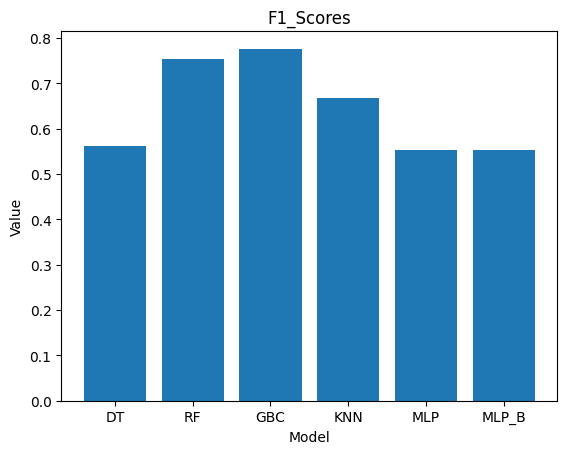

R2_Scores
{'DT': -0.5337056467535399, 'RF': 0.4248603824674225, 'GBC': 0.5891859874767305, 'KNN': 0.4522479833023072, 'MLP': 0.28792237829299927, 'MLP_B': 0.28792237829299927}


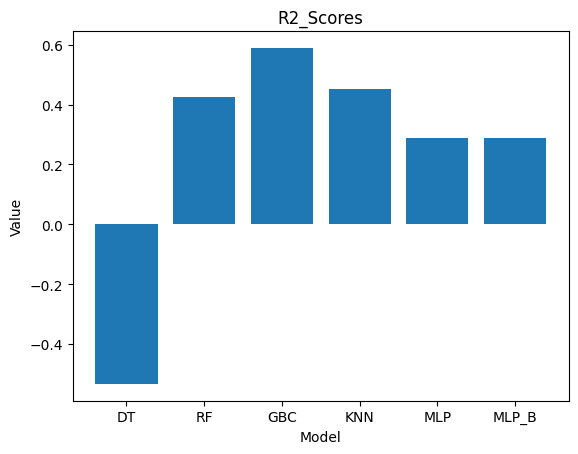

MSE
{'DT': 0.057672502574665295, 'RF': 0.021627188465499485, 'GBC': 0.015447991761071062, 'KNN': 0.02059732234809475, 'MLP': 0.026776519052523172, 'MLP_B': 0.026776519052523172}


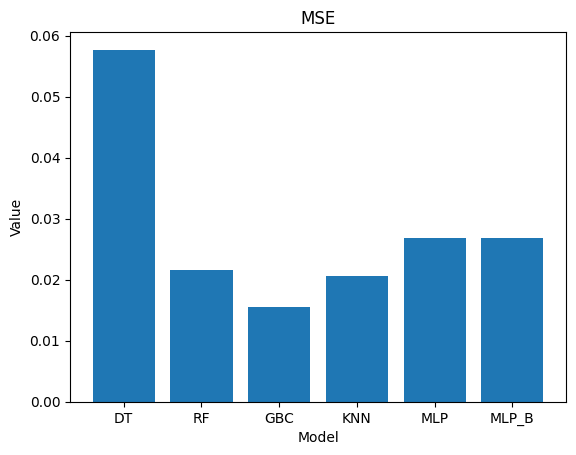

True_Positives
{'DT': np.int64(879), 'RF': np.int64(918), 'GBC': np.int64(930), 'KNN': np.int64(931), 'MLP': np.int64(929), 'MLP_B': np.int64(929)}


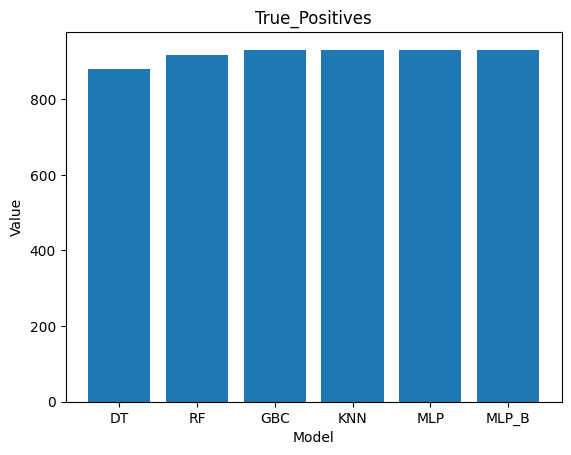

True_Negatives
{'DT': np.int64(36), 'RF': np.int64(32), 'GBC': np.int64(26), 'KNN': np.int64(20), 'MLP': np.int64(16), 'MLP_B': np.int64(16)}


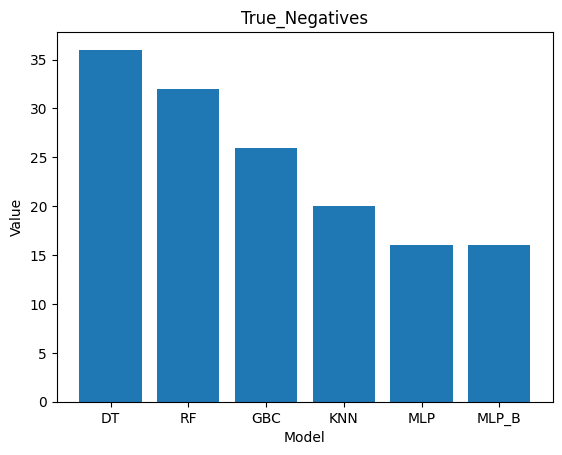

False_Negatives
{'DT': np.int64(54), 'RF': np.int64(15), 'GBC': np.int64(3), 'KNN': np.int64(2), 'MLP': np.int64(4), 'MLP_B': np.int64(4)}


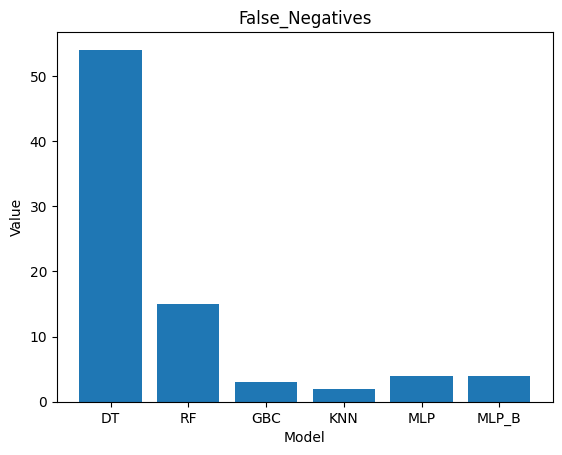

False_Positives
{'DT': np.int64(2), 'RF': np.int64(6), 'GBC': np.int64(12), 'KNN': np.int64(18), 'MLP': np.int64(22), 'MLP_B': np.int64(22)}


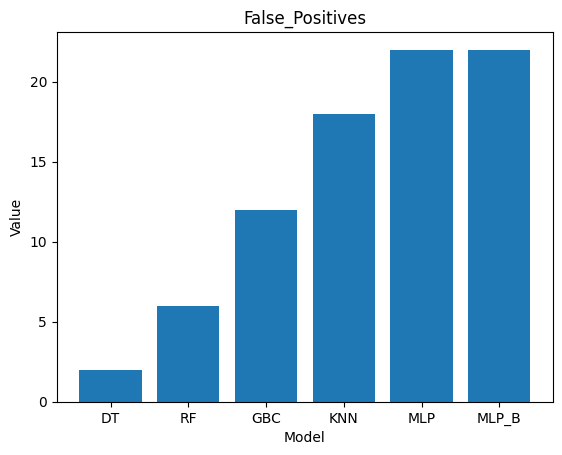

recall
{'DT': 0.9421221864951769, 'RF': 0.9839228295819936, 'GBC': 0.9967845659163987, 'KNN': 0.9978563772775991, 'MLP': 0.9957127545551983, 'MLP_B': 0.9957127545551983}


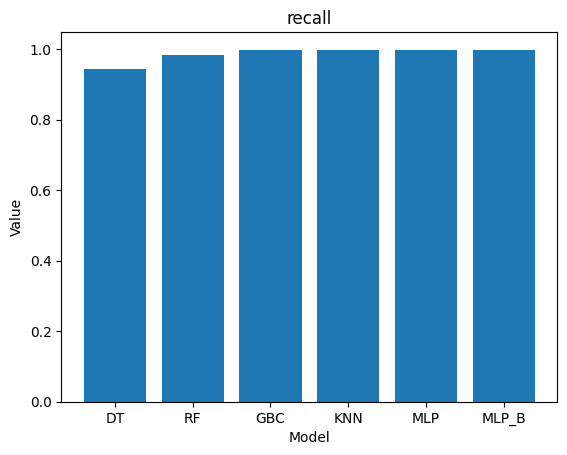

support
{'DT': 933.0, 'RF': 933.0, 'GBC': 933.0, 'KNN': 933.0, 'MLP': 933.0, 'MLP_B': 933.0}


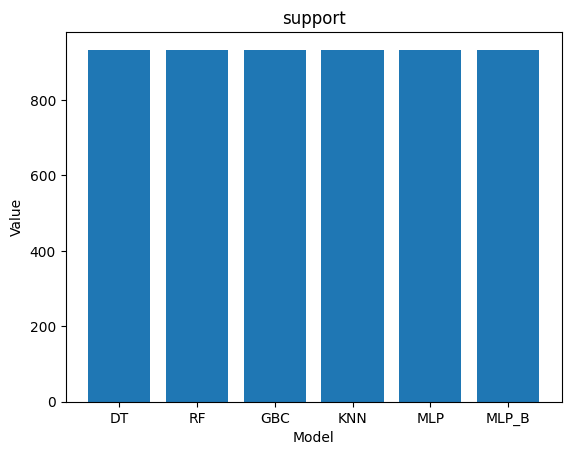

precision
{'DT': 0.9977298524404086, 'RF': 0.9935064935064936, 'GBC': 0.9872611464968153, 'KNN': 0.9810326659641728, 'MLP': 0.9768664563617245, 'MLP_B': 0.9768664563617245}


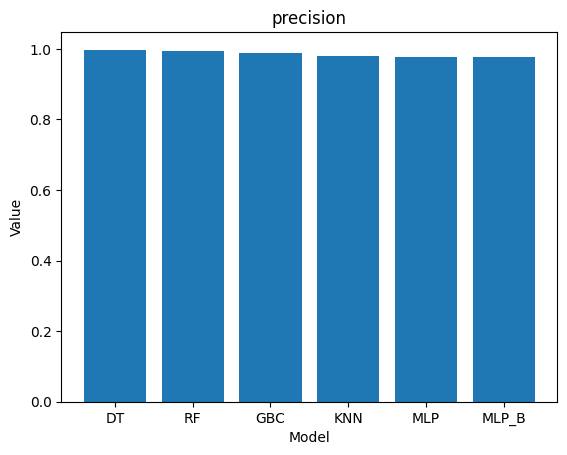

accuracy
{'DT': 0.9423274974253347, 'RF': 0.9783728115345005, 'GBC': 0.984552008238929, 'KNN': 0.9794026776519053, 'MLP': 0.9732234809474768, 'MLP_B': 0.9732234809474768}


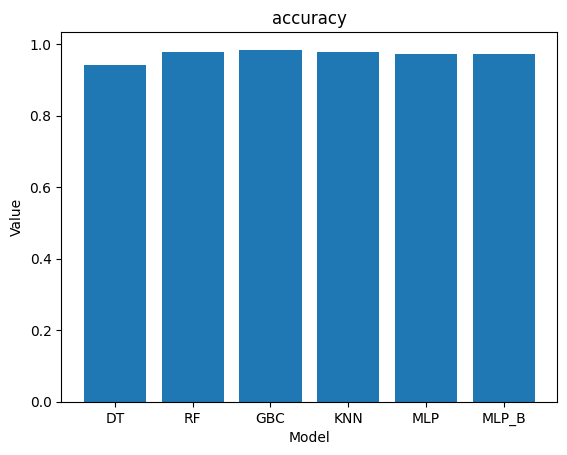

In [213]:
if __name__ == "__main__":
    main()